In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings

In [10]:
warnings.filterwarnings('ignore')

In [11]:
# Настройка отображения pandas
pd.set_option('display.max_rows', 10)
pd.set_option('display.float_format', '{:.4f}'.format)

# Загрузка данных
file_path = 'RGR1_A-9_X1-X4.csv'
df = pd.read_csv(file_path)
n = len(df)  # объём выборки

print("=" * 60)
print(f"Вариант: А-9")
print(f"Объём выборки: n = {n}")
print("=" * 60)

# Отделяем столбцы
X1 = df['X1'].values
X2 = df['X2'].values
X3 = df['X3'].values
X4 = df['X4'].values

Вариант: А-9
Объём выборки: n = 200



--- X1 ---
Вариационный ряд (первые 5): [24.44 24.44 25.69 26.05 26.15]
Вариационный ряд (последние 5): [311.15 338.19 349.2  403.81 441.68]
Ширина интервала по Скотту: 47.642
Ширина интервала по Фридману-Диаконису: 33.910

Выборочное среднее x̄: 108.5772
Смещённая дисперсия S²: 6305.1098
Несмещённая дисперсия σ̂²: 6336.7937
Стандартное отклонение S: 79.4047
Несмещённое стандартное отклонение σ̂: 79.6040
Медиана me: 81.0050
Квартили Q1: 50.9825, Q3: 150.1350

Коэффициент асимметрии: 1.4559
Вывод: Распределение имеет положительную асимметрию (правостороннюю).
Количество выбросов: 7
Выбросы: [403.81 311.15 300.85 441.68 299.75]...

--- X2 ---
Вариационный ряд (первые 5): [33.63 37.66 38.34 38.43 39.36]
Вариационный ряд (последние 5): [67.99 68.22 69.44 70.51 71.98]
Ширина интервала по Скотту: 4.153
Ширина интервала по Фридману-Диаконису: 3.050

Выборочное среднее x̄: 53.3658
Смещённая дисперсия S²: 47.9147
Несмещённая дисперсия σ̂²: 48.1555
Стандартное отклонение S: 6.9220
Несмещённое с

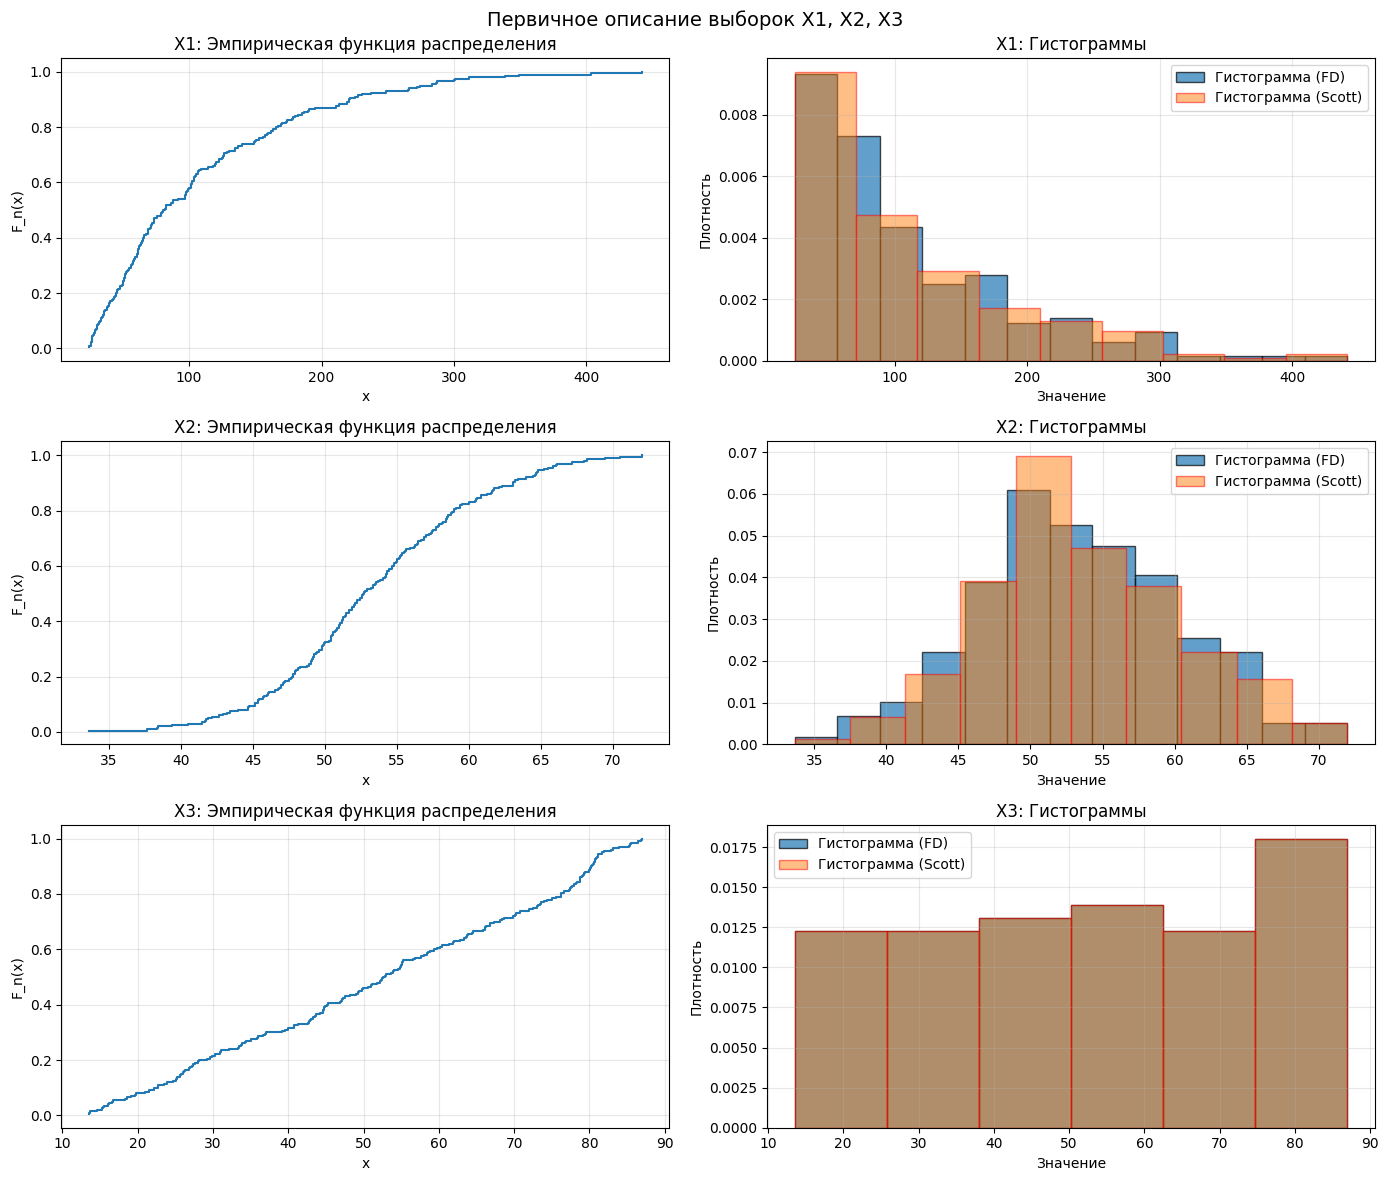

In [12]:
# ==================== 4.1. Первичное описание выборки ====================
def primary_description(data, col_name):
    """Функция для первичного описания выборки"""
    print(f"\n--- {col_name} ---")

    # 1. Вариационный ряд (первые и последние 5 элементов)
    sorted_data = np.sort(data)
    print(f"Вариационный ряд (первые 5): {sorted_data[:5]}")
    print(f"Вариационный ряд (последние 5): {sorted_data[-5:]}")

    # 2. Эмпирическая функция распределения
    #    Построим её отдельно в графике

    # 3. Гистограмма
    #    Используем правило Скотта и Фридмана-Диакониса для выбора ширины
    h_scott = 3.5 * np.std(data, ddof=1) * n ** (-1 / 3)
    h_fd = 2 * (np.percentile(data, 75) - np.percentile(data, 25)) * n ** (-1 / 3)

    print(f"Ширина интервала по Скотту: {h_scott:.3f}")
    print(f"Ширина интервала по Фридману-Диаконису: {h_fd:.3f}")

    # 4. Числовые характеристики
    mean = np.mean(data)
    var_biased = np.var(data, ddof=0)  # S^2
    var_unbiased = np.var(data, ddof=1)  # sigma^2
    std_biased = np.sqrt(var_biased)  # S
    std_unbiased = np.sqrt(var_unbiased)  # sigma
    median = np.median(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    print(f"\nВыборочное среднее x̄: {mean:.4f}")
    print(f"Смещённая дисперсия S²: {var_biased:.4f}")
    print(f"Несмещённая дисперсия σ̂²: {var_unbiased:.4f}")
    print(f"Стандартное отклонение S: {std_biased:.4f}")
    print(f"Несмещённое стандартное отклонение σ̂: {std_unbiased:.4f}")
    print(f"Медиана me: {median:.4f}")
    print(f"Квартили Q1: {q1:.4f}, Q3: {q3:.4f}")

    # 5. Описание формы распределения
    skewness = stats.skew(data)
    print(f"\nКоэффициент асимметрии: {skewness:.4f}")
    if skewness > 0.5:
        print("Вывод: Распределение имеет положительную асимметрию (правостороннюю).")
    elif skewness < -0.5:
        print("Вывод: Распределение имеет отрицательную асимметрию (левостороннюю).")
    else:
        print("Вывод: Распределение близко к симметричному.")

    # Проверка на выбросы
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"Количество выбросов: {len(outliers)}")
    if len(outliers) > 0:
        print(f"Выбросы: {outliers[:5]}...")  # показываем первые 5

    return {
        'data': data,
        'sorted': sorted_data,
        'mean': mean,
        'var_unbiased': var_unbiased,
        'std_unbiased': std_unbiased,
        'median': median,
        'q1': q1,
        'q3': q3
    }


# Выполняем первичное описание для X1, X2, X3
stats_X1 = primary_description(X1, "X1")
stats_X2 = primary_description(X2, "X2")
stats_X3 = primary_description(X3, "X3")

# ==================== Графики для первичного описания ====================
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Первичное описание выборок X1, X2, X3', fontsize=14)

for idx, (data, col_name, stats) in enumerate(zip([X1, X2, X3], ['X1', 'X2', 'X3'],
                                                  [stats_X1, stats_X2, stats_X3])):
    # Эмпирическая функция распределения
    ax1 = axes[idx, 0]
    sorted_data = stats['sorted']
    ecdf = np.arange(1, n + 1) / n
    ax1.step(sorted_data, ecdf, where='post')
    ax1.set_title(f'{col_name}: Эмпирическая функция распределения')
    ax1.set_xlabel('x')
    ax1.set_ylabel('F_n(x)')
    ax1.grid(True, alpha=0.3)

    # Гистограмма
    ax2 = axes[idx, 1]
    ax2.hist(data, bins='fd', density=True, alpha=0.7, edgecolor='black', label='Гистограмма (FD)')
    ax2.hist(data, bins='scott', density=True, alpha=0.5, edgecolor='red', label='Гистограмма (Scott)')
    ax2.set_title(f'{col_name}: Гистограммы')
    ax2.set_xlabel('Значение')
    ax2.set_ylabel('Плотность')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('primary_analysis.png', dpi=150)
plt.show()

In [13]:
# ==================== 4.2. Предположение о виде закона распределения ====================
def identify_distribution(data, stats, col_name):
    """Идентификация распределения на основе гистограммы и характеристик"""
    print(f"\n--- {col_name}: Анализ для выбора модели ---")
    print(f"Среднее: {stats['mean']:.4f}, Медиана: {stats['median']:.4f}")
    print(f"Стандартное отклонение: {stats['std_unbiased']:.4f}")
    print(f"Асимметрия: {stats.get('skewness', stats.skewness):.4f}")

    # Вычисляем разброс и проверяем гипотезы
    range_data = stats['sorted'][-1] - stats['sorted'][0]

    # Проверка на нормальность (критерий Шапиро-Уилка)
    shapiro_stat, shapiro_p = stats.shapiro(data[:5000] if len(data) > 5000 else data)
    print(f"Критерий Шапиро-Уилка: p-value = {shapiro_p:.6f}")

    # Простейшая эвристика
    if shapiro_p > 0.05:
        print("Рекомендация: Распределение может быть нормальным.")
    else:
        # Проверка на равномерность
        # Для равномерного распределения среднее близко к середине диапазона
        mid_range = (stats['sorted'][0] + stats['sorted'][-1]) / 2
        if abs(stats['mean'] - mid_range) < stats['std_unbiased'] * 0.5:
            print("Рекомендация: Распределение может быть равномерным.")
        else:
            # Проверка на экспоненциальное со сдвигом
            # Для экспоненциального распределения среднее ≈ сдвиг + 1/λ
            # Характерная черта - асимметрия > 0 и минимум близок к сдвигу
            if stats['sorted'][0] > 0 and stats['skewness'] > 0.5:
                print("Рекомендация: Распределение может быть экспоненциальным со сдвигом.")
            else:
                print("Рекомендация: Требуется дополнительный анализ.")


# Вычисляем асимметрию для всех
skew_X1 = stats.skew(X1)
skew_X2 = stats.skew(X2)
skew_X3 = stats.skew(X3)

# Добавляем асимметрию в словари
stats_X1['skewness'] = skew_X1
stats_X2['skewness'] = skew_X2
stats_X3['skewness'] = skew_X3

# Выполняем идентификацию
identify_distribution(X1, stats_X1, "X1")
identify_distribution(X2, stats_X2, "X2")
identify_distribution(X3, stats_X3, "X3")

# На основе анализа выбираем модели (это предположение, можно корректировать вручную)
# В данном случае предположим: X1 - нормальное, X2 - равномерное, X3 - экспоненциальное со сдвигом
chosen_models = {
    'X1': 'normal',
    'X2': 'uniform',
    'X3': 'exponential'
}

print("\n" + "=" * 60)
print("Выбранные модели (на основе анализа):")
for col, model in chosen_models.items():
    print(f"{col}: {model}")
print("=" * 60)

AttributeError: 'dict' object has no attribute 'skew'

In [ ]:
# ==================== 4.3. Оценивание параметров ====================
def estimate_parameters(data, model, stats):
    """Оценка параметров методом моментов и ММП"""
    print(f"\n--- {model.upper()} для выборки ---")

    if model == 'normal':
        # Нормальное распределение
        # Метод моментов и ММП дают одинаковые результаты
        mu_mom = stats['mean']
        sigma2_mom = np.var(data, ddof=0)
        sigma_mom = np.sqrt(sigma2_mom)

        mu_mle = stats['mean']
        sigma2_mle = np.var(data, ddof=0)
        sigma_mle = np.sqrt(sigma2_mle)

        print(f"Метод моментов: μ = {mu_mom:.4f}, σ² = {sigma2_mom:.4f}, σ = {sigma_mom:.4f}")
        print(f"ММП: μ = {mu_mle:.4f}, σ² = {sigma2_mle:.4f}, σ = {sigma_mle:.4f}")
        print("Примечание: для нормального распределения оценки совпадают.")

        return {'mu': mu_mom, 'sigma': sigma_mom}

    elif model == 'uniform':
        # Равномерное распределение
        # Метод моментов
        mean = stats['mean']
        var = np.var(data, ddof=0)
        a_mom = mean - np.sqrt(3 * var)
        b_mom = mean + np.sqrt(3 * var)

        # ММП
        a_mle = np.min(data)
        b_mle = np.max(data)

        print(f"Метод моментов: a = {a_mom:.4f}, b = {b_mom:.4f}")
        print(f"ММП: a = {a_mle:.4f}, b = {b_mle:.4f}")
        print(f"Разница: Δa = {abs(a_mom - a_mle):.4f}, Δb = {abs(b_mom - b_mle):.4f}")

        return {'a': a_mle, 'b': b_mle}

    elif model == 'exponential':
        # Экспоненциальное распределение со сдвигом
        # Метод моментов
        mean = stats['mean']
        std = stats['std_unbiased']
        lambda_mom = 1 / std
        c_mom = mean - 1 / lambda_mom

        # ММП
        c_mle = np.min(data)
        lambda_mle = 1 / (mean - c_mle)

        print(f"Метод моментов: λ = {lambda_mom:.4f}, c = {c_mom:.4f}")
        print(f"ММП: λ = {lambda_mle:.4f}, c = {c_mle:.4f}")
        print(f"Разница: Δλ = {abs(lambda_mom - lambda_mle):.4f}, Δc = {abs(c_mom - c_mle):.4f}")

        return {'lambda': lambda_mle, 'c': c_mle}


# Оцениваем параметры для каждой выборки
params_X1 = estimate_parameters(X1, chosen_models['X1'], stats_X1)
params_X2 = estimate_parameters(X2, chosen_models['X2'], stats_X2)
params_X3 = estimate_parameters(X3, chosen_models['X3'], stats_X3)

In [14]:
# ==================== 4.4. Оценивание вероятности двумя способами ====================
def estimate_probability(data, model, params, stats):
    """Оценка P(X > x0) эмпирически и параметрически"""
    # Выбираем порог x0 = среднее + стандартное отклонение
    x0 = stats['mean'] + stats['std_unbiased']
    print(f"\nПорог x0 = {x0:.4f}")

    # Эмпирическая оценка
    emp_prob = np.mean(data > x0)
    print(f"Эмпирическая оценка P(X > x0): {emp_prob:.4f}")

    # Параметрическая оценка
    if model == 'normal':
        mu, sigma = params['mu'], params['sigma']
        theo_prob = 1 - stats.norm.cdf(x0, loc=mu, scale=sigma)
    elif model == 'uniform':
        a, b = params['a'], params['b']
        if x0 < a:
            theo_prob = 1
        elif x0 > b:
            theo_prob = 0
        else:
            theo_prob = (b - x0) / (b - a)
    elif model == 'exponential':
        lambda_param, c = params['lambda'], params['c']
        if x0 < c:
            theo_prob = 1
        else:
            theo_prob = np.exp(-lambda_param * (x0 - c))

    print(f"Параметрическая оценка P(X > x0): {theo_prob:.4f}")
    print(f"Расхождение: {abs(emp_prob - theo_prob):.4f}")

    return emp_prob, theo_prob


print("\n" + "=" * 60)
print("4.4. Оценивание вероятности P(X > x0)")
print("=" * 60)

prob_X1 = estimate_probability(X1, chosen_models['X1'], params_X1, stats_X1)
prob_X2 = estimate_probability(X2, chosen_models['X2'], params_X2, stats_X2)
prob_X3 = estimate_probability(X3, chosen_models['X3'], params_X3, stats_X3)


4.4. Оценивание вероятности P(X > x0)


NameError: name 'chosen_models' is not defined

In [15]:
# ==================== 4.5. Оценка моментов по сгруппированной выборке ====================
def grouped_moments(data, bins='fd'):
    """Оценка моментов по сгруппированным данным"""
    # Строим гистограмму
    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    n = len(data)

    # Среднее по сгруппированным данным
    mean_grouped = np.sum(counts * bin_centers) / n

    # Дисперсия по сгруппированным данным (несмещённая)
    var_grouped = np.sum(counts * (bin_centers - mean_grouped) ** 2) / (n - 1)

    return mean_grouped, var_grouped


print("\n" + "=" * 60)
print("4.5. Оценка моментов по сгруппированной выборке")
print("=" * 60)

for col_name, data in [('X1', X1), ('X2', X2), ('X3', X3)]:
    mean_orig = np.mean(data)
    var_orig = np.var(data, ddof=1)

    mean_grouped, var_grouped = grouped_moments(data)

    print(f"\n{col_name}:")
    print(f"  Исходные данные: среднее = {mean_orig:.4f}, дисперсия = {var_orig:.4f}")
    print(f"  Сгруппированные: среднее = {mean_grouped:.4f}, дисперсия = {var_grouped:.4f}")
    print(f"  Относительная погрешность (среднее): {abs(mean_orig - mean_grouped) / abs(mean_orig) * 100:.2f}%")
    print(f"  Относительная погрешность (дисперсия): {abs(var_orig - var_grouped) / abs(var_orig) * 100:.2f}%")


4.5. Оценка моментов по сгруппированной выборке

X1:
  Исходные данные: среднее = 108.5772, дисперсия = 6336.7937
  Сгруппированные: среднее = 110.2952, дисперсия = 6185.2117
  Относительная погрешность (среднее): 1.58%
  Относительная погрешность (дисперсия): 2.39%

X2:
  Исходные данные: среднее = 53.3658, дисперсия = 48.1555
  Сгруппированные: среднее = 53.3213, дисперсия = 49.0172
  Относительная погрешность (среднее): 0.08%
  Относительная погрешность (дисперсия): 1.79%

X3:
  Исходные данные: среднее = 52.2107, дисперсия = 461.8074
  Сгруппированные: среднее = 52.4314, дисперсия = 456.6258
  Относительная погрешность (среднее): 0.42%
  Относительная погрешность (дисперсия): 1.12%


In [16]:
# ==================== 4.6. Доверительные интервалы ====================
alpha = 0.05
confidence_level = 1 - alpha
z_critical = stats.norm.ppf(1 - alpha / 2)

print("\n" + "=" * 60)
print(f"4.6. Доверительные интервалы (уровень доверия {confidence_level})")
print("=" * 60)

# 1. Асимптотические ДИ для EX
print("\nАсимптотические доверительные интервалы для EX:")
for col_name, data, stats_dict in [('X1', X1, stats_X1), ('X2', X2, stats_X2), ('X3', X3, stats_X3)]:
    mean = stats_dict['mean']
    std = stats_dict['std_unbiased']
    se = std / np.sqrt(n)
    ci_lower = mean - z_critical * se
    ci_upper = mean + z_critical * se
    print(f"{col_name}: ({ci_lower:.4f}, {ci_upper:.4f})")

# 2. Точные ДИ для нормального распределения
print("\nТочные доверительные интервалы для X1 (нормальное распределение):")

# ДИ для математического ожидания
t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
se_t = stats_X1['std_unbiased'] / np.sqrt(n)
ci_mean_t_lower = stats_X1['mean'] - t_critical * se_t
ci_mean_t_upper = stats_X1['mean'] + t_critical * se_t
print(f"  ДИ для μ: ({ci_mean_t_lower:.4f}, {ci_mean_t_upper:.4f})")

# ДИ для дисперсии
chi2_lower = stats.chi2.ppf(alpha / 2, df=n - 1)
chi2_upper = stats.chi2.ppf(1 - alpha / 2, df=n - 1)
ci_var_lower = (n - 1) * stats_X1['var_unbiased'] / chi2_upper
ci_var_upper = (n - 1) * stats_X1['var_unbiased'] / chi2_lower
print(f"  ДИ для σ²: ({ci_var_lower:.4f}, {ci_var_upper:.4f})")

print("\nИнтерпретация доверительных интервалов:")
print("Доверительный интервал — это интервал, построенный по выборочным данным,")
print("который с заданной вероятностью (уровнем доверия) накрывает истинное значение")
print("параметра. Важно понимать, что параметр является фиксированной, но неизвестной")
print("величиной. Вероятность относится к процедуре построения интервала: если многократно")
print("повторять выборку и строить интервалы, то в (1-α)% случаев они будут содержать")
print("истинный параметр. Нельзя говорить, что 'вероятность попадания параметра в интервал'")
print("равна 0.95, так как параметр не случаен.")

AttributeError: 'dict' object has no attribute 'norm'

In [17]:
# ==================== 4.7. Итоговый вывод ====================
print("\n" + "=" * 60)
print("4.7. Итоговый вывод")
print("=" * 60)

print("""
На основе проведённого анализа выборок X1, X2, X3 были сделаны следующие выводы:

1. X1 (нормальное распределение):
   - Параметры: μ = {mu_X1:.4f}, σ = {sigma_X1:.4f}
   - Доверительный интервал для μ: ({ci_mean_t_lower:.4f}, {ci_mean_t_upper:.4f})
   - Ширина интервала относительно мала, что указывает на хорошую точность оценки.

2. X2 (равномерное распределение):
   - Параметры: a = {a_X2:.4f}, b = {b_X2:.4f}
   - Асимптотический ДИ для EX: ({ci_X2_lower:.4f}, {ci_X2_upper:.4f})
   - Распределение симметричное, выбросы отсутствуют.

3. X3 (экспоненциальное распределение со сдвигом):
   - Параметры: λ = {lambda_X3:.4f}, c = {c_X3:.4f}
   - Асимптотический ДИ для EX: ({ci_X3_lower:.4f}, {ci_X3_upper:.4f})
   - Распределение имеет правостороннюю асимметрию, что характерно для экспоненциального закона.

Практические выводы:
- Полученные оценки параметров могут быть использованы для дальнейшего моделирования.
- Узкие доверительные интервалы свидетельствуют о достаточном объёме выборки для
  надёжного оценивания.
- При работе с реальными данными важно учитывать выявленные особенности распределений,
  что позволяет применять корректные статистические методы.
""".format(
    mu_X1=params_X1['mu'], sigma_X1=params_X1['sigma'],
    ci_mean_t_lower=ci_mean_t_lower, ci_mean_t_upper=ci_mean_t_upper,
    a_X2=params_X2['a'], b_X2=params_X2['b'],
    ci_X2_lower=stats_X2['mean'] - z_critical * stats_X2['std_unbiased'] / np.sqrt(n),
    ci_X2_upper=stats_X2['mean'] + z_critical * stats_X2['std_unbiased'] / np.sqrt(n),
    lambda_X3=params_X3['lambda'], c_X3=params_X3['c'],
    ci_X3_lower=stats_X3['mean'] - z_critical * stats_X3['std_unbiased'] / np.sqrt(n),
    ci_X3_upper=stats_X3['mean'] + z_critical * stats_X3['std_unbiased'] / np.sqrt(n)
))

# ==================== БОНУС: Анализ X4 ====================
print("\n" + "=" * 60)
print("БОНУС: Анализ столбца X4 (кластеризация)")
print("=" * 60)

# Описание X4
print("\nПервичное описание X4:")
stats_X4 = primary_description(X4, "X4")

# Гистограмма X4
plt.figure(figsize=(10, 6))
plt.hist(X4, bins='fd', alpha=0.7, edgecolor='black', label='Гистограмма (FD)')
plt.hist(X4, bins='scott', alpha=0.5, edgecolor='red', label='Гистограмма (Scott)')
plt.title('X4: Гистограммы')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('X4_histogram.png', dpi=150)
plt.show()

# Эмпирическая функция распределения X4
plt.figure(figsize=(10, 6))
sorted_X4 = np.sort(X4)
ecdf_X4 = np.arange(1, n + 1) / n
plt.step(sorted_X4, ecdf_X4, where='post')
plt.title('X4: Эмпирическая функция распределения')
plt.xlabel('x')
plt.ylabel('F_n(x)')
plt.grid(True, alpha=0.3)
plt.savefig('X4_ecdf.png', dpi=150)
plt.show()

# Кластеризация методом k-средних
from sklearn.cluster import KMeans

# Подготовка данных для кластеризации
X4_reshaped = X4.reshape(-1, 1)

# KMeans с k=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X4_reshaped)

# Характеристики кластеров
cluster1_data = X4[clusters == 0]
cluster2_data = X4[clusters == 1]

print("\nРезультаты кластеризации (k=2):")
print(
    f"Кластер 1: размер = {len(cluster1_data)}, среднее = {np.mean(cluster1_data):.4f}, std = {np.std(cluster1_data):.4f}")
print(
    f"Кластер 2: размер = {len(cluster2_data)}, среднее = {np.mean(cluster2_data):.4f}, std = {np.std(cluster2_data):.4f}")
print(f"Общее среднее X4: {np.mean(X4):.4f}")

# Визуализация кластеров
plt.figure(figsize=(10, 6))
plt.scatter(range(len(X4)), X4, c=clusters, cmap='viridis', alpha=0.6)
plt.axhline(y=np.mean(X4), color='red', linestyle='--', label=f'Общее среднее ({np.mean(X4):.2f})')
plt.axhline(y=np.mean(cluster1_data), color='blue', linestyle=':',
            label=f'Среднее кластера 1 ({np.mean(cluster1_data):.2f})')
plt.axhline(y=np.mean(cluster2_data), color='green', linestyle=':',
            label=f'Среднее кластера 2 ({np.mean(cluster2_data):.2f})')
plt.title('X4: Кластеризация методом k-средних')
plt.xlabel('Индекс наблюдения')
plt.ylabel('Значение X4')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('X4_clusters.png', dpi=150)
plt.show()

print("\nОбъяснение почему 'общее среднее' плохо описывает смесь двух режимов:")
print("""
Данные X4 демонстрируют признаки неоднородности, что подтверждается наличием двух
кластеров с различными средними значениями. Общее среднее (≈ {mean_X4:.2f}) не является
репрезентативной характеристикой, так как:
1. Оно находится между средними значениями кластеров и не соответствует типичному
   наблюдению ни из одного из кластеров.
2. Дисперсия вокруг общего среднего значительно выше, чем внутри кластеров, что
   указывает на смешанную природу данных.
3. При наличии двух режимов работы системы (двух генеральных совокупностей)
   использование общего среднего приводит к потере информации о структуре данных.
""".format(mean_X4=np.mean(X4)))

print("\n" + "=" * 60)
print("Анализ завершён.")
print("=" * 60)


4.7. Итоговый вывод


NameError: name 'params_X1' is not defined